In [26]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")
import matplotlib.pyplot as plt
import cv2
import imutils
import numpy as np
from PIL import Image
from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object, label_wrist_image_rotation_axes
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
from magpie_control import poses
import spatialmath as sm
reload_modules(pcd, utils, real, ur5, gripper)

import os
from google import genai
import openai
from dotenv import load_dotenv
import instructor
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
reload_modules(sf_force_thinker, sf_grasp_selection, conversation, sf_force_reflection)

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENAI_API_KEY = os.getenv('CORRELL_API_KEY')
GEMINI_MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}
# OPENAI_MODEL_ID = "gpt-4o-mini"
OPENAI_MODEL_ID = "gpt-4o"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
force_thinker = sf_force_thinker.PromptForceThinker()

In [2]:
# # load everything
gripper_log = np.load("scalingforce/gripper_log.npy", allow_pickle=True).item()
robot_log   = np.load("scalingforce/robot_log.npy",   allow_pickle=True).item()
wrist_log   = np.load("scalingforce/wrist_log.npy",   allow_pickle=True).item()
wkspc_log   = np.load("scalingforce/wkspc_log.npy",   allow_pickle=True).item()

gripper_ts   = sorted(gripper_log.keys())
robot_ts   = sorted(robot_log.keys())
wrist_ts = sorted(wrist_log.keys())
wkspc_ts   = sorted(wkspc_log.keys())

/tmp/ipykernel_5648/1856488511.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(point_proj[0]), int(point_proj[1])


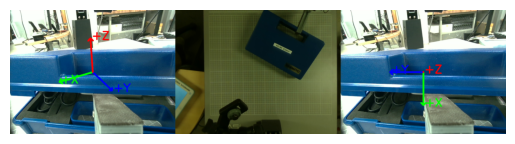

In [22]:
wrist_img_init = wrist_log[wrist_ts[0]]['rgb']
wkspc_img_init = wkspc_log[wkspc_ts[0]]['rgb']

R_cw = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
T_wr = np.array(sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[robot_ts[0]]['actual_TCP_pose']))))
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T

intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
wrist_img_labeled = label_wrist_image_rotation_axes(wrist_img_init.copy(), R_cw, intrinsics, axis_length=0.03)
wrist_img_labeled_base = label_wrist_image_rotation_axes(wrist_img_init.copy(), R_cr, intrinsics, axis_length=0.03)
init_img = np.hstack((wrist_img_labeled_base, wkspc_img_init, wrist_img_labeled))
img_PIL = Image.fromarray(init_img)
# wrist_init_rotated = cv2.rotate(wrist_img_init, cv2.ROTATE_90_COUNTERCLOCKWISE)
# wrist_img_labeled = label_wrist_image(wrist_init_rotated.copy())
# wkspc_init_resized = imutils.resize(wkspc_img_init, height=wrist_init_rotated.shape[0])
# init_img = np.hstack((wkspc_init_resized, wrist_img_labeled))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(init_img)

In [29]:
model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    client_structured = instructor.from_openai(client=client)
    model = OPENAI_MODEL_ID
elif model_type == "gemini":
    client = gemini_client
    client_structured = instructor.from_genai(client=client)
    model = GEMINI_MODEL_ID
# img = Image.open('scalingforce/axes7_double_wrist.png').convert("RGB")\
img = img_PIL

# obj = "small servo motor"
prompt_config = {
"obj": "blue case top handle",
"task": "open the blue case"
}
# obj = "small servo motor"
# prompt_config = {
# "obj": "small servo motor",
# "task": f"slide the {obj} rapidly up the table for 10 cm"
# }

messages = []
prompt = sf_force_thinker.prompt_motion_thinker.format(**prompt_config)
messages = build_messages(prompt, img, messages=messages, model_type=model_type)
response = send_message(client, model, messages, model_type=model_type)
motion_plan = force_thinker.process_thinker_response(response)
# np.save("scalingforce/motion_plan.npy", motion_plan, allow_pickle=True)
print(response)
print(motion_plan)

[start of motion plan]
The task is to open the blue case while grasping the blue case top handle.

Aligning Images With Wrist Motion:
The provided images in the three-part image confirm the presence of a blue case with a handle, resting on a flat surface, likely a table. The task requires grasping the handle and opening the case, implying a hinged connection and potential resistance to opening. The case is likely made of plastic and contains some items inside.
The green axis representing the positive X-axis along the wrist corresponds to upward motion, which is important to lift the handle and open the case.
The blue axis representing negative Y-axis along the wrist corresponds to pulling the handle away from the base of the case to initiate the opening.
The red dot representing the positive Z-axis (into the page) along the wrist corresponds to moving the wrist in the left direction with respect to the object, which is not immediately necessary for the open action.
Thus, the required l

/tmp/ipykernel_5648/1856488511.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(point_proj[0]), int(point_proj[1])


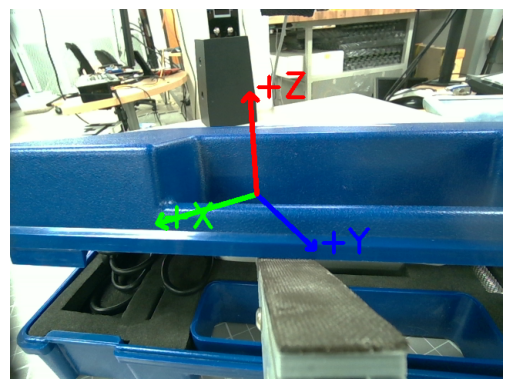

In [20]:
# # T_wc = np.eye(4)
# # rot = np.array([
# #     [0, 1, 0],
# #     [-1,  0, 0],
# #     [0,  0, 1]
# # ])

# # t = np.array([
# #     [-1.15 / 100],
# #     [ 1.3  / 100],
# #     [(309.63 - 195.0) / 1000]
# # ])
# # T_cw = np.eye(4)
# # T_cw[:3, :3] = rot
# # T_cw[:3, 3] = t.flatten()
# # T_wc = np.linalg.inv(T_cw)
# # R_wc = T_wc[:3, :3]
# R_cw = np.array([
#     [0, -1, 0],
#     [1,  0, 0],
#     [0,  0, 1]
# ])
# T_wr = np.array(sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[robot_ts[0]]['actual_TCP_pose']))))
# R_wr = T_wr[:3, :3]
# # T_rw = np.linalg.inv(T_wr)
# # T_rc = T_wc @ T_rw
# # R_rc = T_rc[:3, :3]
# R_rc = R_cw @ R_wr.T
# # print("T_wc", T_wc)
# # print("T_rc", T_rc)
# # print("R_wc", R_wc)
# # print("R_rc", R_rc)
# R_i = np.eye(3)

# intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
# # img_labeled = label_wrist_image(wrist_img_init.copy(), R_wc, intrinsics, axis_length=0.03)
# img_labeled = label_wrist_image_rotation_axes(wrist_img_init.copy(), R_rc, intrinsics, axis_length=0.03)
# plt.xticks([])
# plt.yticks([])
# plt.axis('off')
# plt.imshow(img_labeled)

In [42]:
model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    client_structured = instructor.from_openai(client=client)
    model = OPENAI_MODEL_ID
    # model = "gpt-4o-mini"
elif model_type == "gemini":
    client = gemini_client
    client_structured = instructor.from_genai(client=client)
    model = GEMINI_MODEL_ID
img = Image.fromarray(init_img).convert("RGB")
# img = Image.fromarray(wrist_img_labeled).convert("RGB")

prompt_config = {
"obj": "blue case top handle",
"task": "open the blue case"
}

messages = []
prompt = sf_force_thinker.prompt_motion_thinker.format(**prompt_config)
messages = build_messages(prompt, img, messages=messages, model_type=model_type)
response = send_message(client, model, messages, model_type=model_type)
motion_plan = force_thinker.process_thinker_response(response)
# np.save("scalingforce/motion_plan.npy", motion_plan, allow_pickle=True)
motion_plan

{'position_direction': [1, -1, 0],
 'position_goal': [0.1, 0.02, 0.0],
 'force': [3.0, 1.0, 0.0],
 'grasp_force': 7.5,
 'duration': 2.0}

In [43]:
print(response)

[start of motion plan]
The task is to open the blue case while grasping the blue case top handle.

Aligning Image With Motion:
The provided image confirms the presence of a blue case with a handle, situated on a surface. The task involves grasping the handle and opening the case.
The green axis pointing to the right of the image is the positive X-axis, corresponding to the direction the case needs to swing to open.
The blue axis pointing up the image is the negative Y-axis, corresponding to upward lift that may be required to free the case from latch friction.
The red dot pointing into the image is the positive Z-axis, corresponding to potentially no motion directly along the Z axis, but force may be required to maintain contact.

Position Motion Required:
X-axis: Movement is required in the positive X-axis to swing the case open.

Y-axis: Movement is required in the negative Y-axis to lift the case slightly.

Z-axis: No motion required.

To estimate the forces required to accomplish o

In [1]:
motion_plan = np.load("scalingforce/motion_plan.npy", allow_pickle=True).item()
motion_plan

goal_delta = np.array(motion_plan['position_goal'])
direction = np.array(motion_plan['position_direction'])
sign = np.where(direction < 0, -1, 1)
force = np.array(motion_plan['force']) * sign
wrench_goal = np.hstack((force, np.zeros(3)))
init_cmd = np.hstack((force / -300, np.zeros(3)))
duration = motion_plan['duration']
# duration = 5
grasp_force = motion_plan['grasp_force']
P = 0.0003 # stiffness gain, default is 0.0005


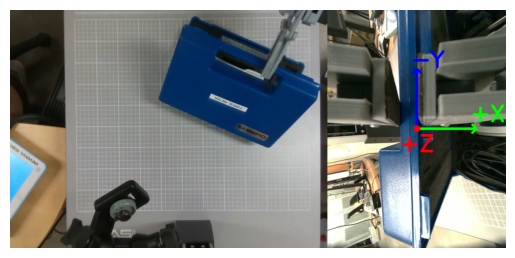

In [89]:
wrist_img_final = wrist_log[wrist_ts[-1]]['rgb']
wkspc_img_final = wkspc_log[wkspc_ts[-1]]['rgb']

wrist_final_rotated = cv2.rotate(wrist_img_final, cv2.ROTATE_90_COUNTERCLOCKWISE)
wrist_img_labeled = label_wrist_image(wrist_final_rotated.copy())
wkspc_final_resized = imutils.resize(wkspc_img_final, height=wrist_final_rotated.shape[0])
# final_img = np.hstack((img_wkspc_resized, wrist_img_labeled))
# final_img = np.hstack((img_wkspc_resized, wrist_img2_labeled))
final_img = np.hstack((wkspc_final_resized, wrist_img_labeled))
# cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(final_img)

In [179]:
from spatialmath.base import rodrigues, tr2rpy
import numpy as np

motion_report = ""
# motion_report += f"Initial Motion Plan: {motion_plan}\n"
# get first and last TCP pose of robot log
first_pose = np.array(robot_log[robot_ts[0]]['actual_TCP_pose'])
last_pose =  np.array(robot_log[robot_ts[-1]]['actual_TCP_pose'])
dist =  last_pose - first_pose
# get the rotation matrix from the wrist frame to the robot frame
rot = rodrigues(first_pose[3:6])
# transform distance to be relative to the first TCP wrist frame, use inverse of rot
dist_wrist = rot.T @ dist[:3]
motion_report += f"Motion Plan Results: \nDistance traveled along wrist base frame [x, y, z] (m) axes: {dist_wrist}\n"
motion_report += f"Distance traveled along base frame [x, y, z] (m) axes: {dist[:3]}\n"

# Use a simple moving average with a window size of downsample_factor
def moving_average(data, window_size):
    return np.array([np.mean(data[i:i+window_size], axis=0) for i in range(0, len(data), window_size)])

def get_report(desired_freq, timestamps, log, name, description):
    log_dur = timestamps[-1] - timestamps[0]
    log_flat = np.array([log[i][name] for i in timestamps])
    num_downsampled_entries = int(log_dur // (1 / desired_freq))
    downsample_factor = len(timestamps) // num_downsampled_entries
    downsampled_log = moving_average(log_flat, downsample_factor)
    summary = f"\n{description} Log Summary:"
    summary += f"\nMotion Duration: {log_dur}s"
    summary += f"\nAverage {name} Downsampled at {desired_freq}Hz:"
    for i, entry in enumerate(downsampled_log):
        summary += f"\n{i*(1/desired_freq)}s to {(i+1)*(1/desired_freq)}: {entry.round(2)}"
    return summary
desired_freq = 2
wrench_report = get_report(desired_freq, robot_ts, robot_log, "wrench", "6D Wrench [x, y, z, rx, ry, rz] (N and Nm)")
# print(wrench_report)
motion_report += f"{wrench_report}\n"

for i in gripper_log: gripper_log[i]['cf'] *= 2
gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf", "Gripper Contact Force (N)")
# print(gripper_report)
motion_report += f"{gripper_report}\n"

print(motion_report)

Motion Plan Results: 
Distance traveled along wrist base frame [x, y, z] (m) axes: [-0.072  0.048 -0.003]
Distance traveled along base frame [x, y, z] (m) axes: [ 0.025 -0.049  0.067]

6D Wrench [x, y, z, rx, ry, rz] (N and Nm) Log Summary:
Motion Duration: 2.9850471019744873s
Average wrench Downsampled at 2Hz:
0.0s to 0.5: [ 0.14 -0.21 -1.36  0.02  0.05 -0.  ]
0.5s to 1.0: [-0.03 -0.66 -1.16  0.07  0.02  0.01]
1.0s to 1.5: [ 0.43 -2.2   0.93  0.26  0.07  0.05]
1.5s to 2.0: [ 1.07 -2.29  1.1   0.29  0.19  0.06]
2.0s to 2.5: [ 1.58 -2.19  1.43  0.27  0.24  0.02]
2.5s to 3.0: [ 2.   -1.7   1.5   0.23  0.29 -0.03]

Gripper Contact Force (N) Log Summary:
Motion Duration: 2.9574172496795654s
Average cf Downsampled at 2Hz:
0.0s to 0.5: 33.11
0.5s to 1.0: 5.97
1.0s to 1.5: 161.23
1.5s to 2.0: 235.86
2.0s to 2.5: 239.39
2.5s to 3.0: 237.05



In [183]:
print(motion_report)

Motion Plan Results: 
Distance traveled along wrist base frame [x, y, z] (m) axes: [-0.072  0.048 -0.003]
Distance traveled along base frame [x, y, z] (m) axes: [ 0.025 -0.049  0.067]

6D Wrench [x, y, z, rx, ry, rz] (N and Nm) Log Summary:
Motion Duration: 2.9850471019744873s
Average wrench Downsampled at 2Hz:
0.0s to 0.5: [ 0.14 -0.21 -1.36  0.02  0.05 -0.  ]
0.5s to 1.0: [-0.03 -0.66 -1.16  0.07  0.02  0.01]
1.0s to 1.5: [ 0.43 -2.2   0.93  0.26  0.07  0.05]
1.5s to 2.0: [ 1.07 -2.29  1.1   0.29  0.19  0.06]
2.0s to 2.5: [ 1.58 -2.19  1.43  0.27  0.24  0.02]
2.5s to 3.0: [ 2.   -1.7   1.5   0.23  0.29 -0.03]

Gripper Contact Force (N) Log Summary:
Motion Duration: 2.9574172496795654s
Average cf Downsampled at 2Hz:
0.0s to 0.5: 33.11
0.5s to 1.0: 5.97
1.0s to 1.5: 161.23
1.5s to 2.0: 235.86
2.0s to 2.5: 239.39
2.5s to 3.0: 237.05



In [180]:
messages

['\nGiven the user instruction and image, generate a structured physical plan for a robot end-effector interacting with the environment.\n\nThe robot is controlled using position and torque-based control, with access to contact feedback and 6D motion capabilities. \nMotions can include grasping, lifting, pushing, tapping, sliding, rotating, or any interaction with objects or surfaces.\n\nAssume the robot has access to:\n- Object geometry and contact points (from the image)\n- Force/torque sensing at the wrist\n- Prior knowledge of object material types and mass estimates\n- Environmental knowledge (table, gravity, hinge resistance, etc.)\n\nUse physical reasoning to complete the following plan in a structured format.\n\n[start of motion plan]\nThe task is to open the blue case while grasping the blue case top handle.\n\nAligning Image With Motion:\nThe right image is labeled with the axes of motion relative to the wrist of the robot. \nThe wrist of the robot may be oriented differently

In [199]:
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
reload_modules(sf_force_thinker, sf_grasp_selection, conversation, sf_force_reflection)

feedback_messages = messages.copy()
feedback_messages.append(response)
feedback_prompt_config = prompt_config.copy()
feedback_prompt_config['results'] = motion_report
feedback_prompt = sf_force_reflection.prompt_motion_reflection.format(**feedback_prompt_config)
img_final_PIL = Image.fromarray(final_img).convert("RGB")
feedback_messages = build_messages(feedback_prompt, img_final_PIL, messages=feedback_messages, model_type=model_type)
feedback_response = send_message(client, model, feedback_messages, model_type=model_type)

In [204]:
print(feedback_response)
force_reflector = sf_force_reflection.PromptForceReflection()
motion_feedback_plan = force_reflector.process_thinker_response(feedback_response)
print(motion_feedback_plan)

[beginning of reflection]
Reflection on Task Completion:
- The provided two-part image and change in position confirms the robot was able to accomplish the task of open the blue case while grasping the blue case top handle.
- This is based on the following observations: The image shows that the case is open relative to the starting position. The wrist camera also shows the open case.
- If the task was incomplete, describe the task state: The task has been completed!
- The estimated task duration was sufficient with the actual task duration.

Reflection on Motion:
- The provided two-part image and change in position confirms the robot was able to exert the estimated forces or move to the correct positions required to accomplish the task of open the blue case while grasping the blue case top handle.
- The change in position relative to the wrist was consistent with the estimated position because the case is visibly open, and there is expected X axis and minimal Y axis motion.
- The chang